# Hospital Access in Wisconsin
**Team Number:** Group 27  
**Members:** Ashley Swenson, Alex Wong, Avanti Kekane, Tanvi Raman

## Overview
This notebook contains the data cleaning, exploratory analysis, and choropleth 
visualizations for our study of hospital access in Wisconsin. We examine county-level 
relationships between mortality rates, elderly poverty rates, population age, and 
uninsured rates to identify which counties may be most in need of healthcare resources.

This notebook is organized into three sections:
1. Data loading and cleaning
2. Exploratory visualizations(scatter plot, bar chart, geopandas map)
3. Interactive choropleth maps built with Plotly and Dash

Member Names: Ashley Swenson, Alex Wong, Avanti Kekane, Tanvi Raman 
Team Number: Group 27


In [2]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import json
import geopandas
from shapely.geometry import Point
import plotly.express as px
from dash import Dash, dcc, html, callback, Output, Input

In [3]:
'''
Socioeconomic profile data for Wisconsin counties, focused on the 65+ population.
Includes poverty rates, age breakdowns, and income thresholds by county.

Source: Wisconsin Department of Health Services
URL: https://www.dhs.wisconsin.gov/publications/p01213.xlsx
'''
profile = pd.read_excel('wi_county_profile.xlsx', skiprows=2)
profile.rename(columns={profile.columns[0]: 'County'}, inplace=True)
profile.columns = profile.columns.str.strip()
profile.head()

,County,"Total Population - All Ages, All Races",60+,65+,75+,85+,% 60+,% 65+,% 75+,% 85+,...,Rental costs less than 30% of income,Percent with rental costs <30% of income,Rental costs 30% of income or more,Percent with rental costs >=30% of income or more,Number of units that are owner-occupied,Percent of units that are owner-occupied,Monthly owner costs less than 30% of income,Percent with monthly owner costs <30% of income,Monthly owner costs 30% of income or more,Percent with owner costs >=30% of income
0,Wisconsin,5914872,1514099,1096043,434379,124459,0.255982,0.185303,0.073438,0.021042,...,56619,0.358251,87122,0.551255,546591,0.775709,413533,0.756568,128749,0.235549
1,Adams,21123,9045,6803,2595,668,0.428206,0.322066,0.122852,0.031624,...,104,0.312312,126,0.378378,3952,0.922287,2866,0.725202,1052,0.266194
2,Ashland,16080,4731,3452,1316,459,0.294216,0.214677,0.081841,0.028545,...,166,0.340862,243,0.498973,1805,0.787522,1361,0.754017,439,0.243213
3,Barron,46797,14886,11028,4690,1241,0.318097,0.235656,0.100220,0.026519,...,558,0.382979,633,0.434454,5608,0.793772,4281,0.763374,1310,0.233595
4,Bayfield,16575,6838,5185,1901,497,0.412549,0.312821,0.114691,0.029985,...,152,0.406417,164,0.438503,2914,0.886253,2264,0.776939,645,0.221345


In [4]:
'''
We only keep the columns relevant to our analysis.
These columns capture population size, age distribution, and poverty rates among the 65+ population.
'''
needed_columns = [
    'County',
    'Total Population - All Ages, All Races',
    '% 65+',
    '% 75+',
    '% 85+',
    'Persons age 65+ (for poverty)',
    'Persons 65+ in poverty',
    '% of persons 65+ in poverty',
    'Total, Age 65+*',
    '% of 65+ Pop below poverty',
    '% of 65+ Pop: 150% of poverty or less',
    '% of 65+ Pop: 185% of poverty or less',
    '% of 65+ Pop: 200% of poverty or less',
    '% of 65+ Pop: 300% of poverty or less'
]
profile_final = profile[needed_columns].copy()
profile_final.set_index('County', inplace=True)
profile_final.head()

,"Total Population - All Ages, All Races",% 65+,% 75+,% 85+,Persons age 65+ (for poverty),Persons 65+ in poverty,% of persons 65+ in poverty,"Total, Age 65+*",% of 65+ Pop below poverty,% of 65+ Pop: 150% of poverty or less,% of 65+ Pop: 185% of poverty or less,% of 65+ Pop: 200% of poverty or less,% of 65+ Pop: 300% of poverty or less
County,,,,,,,,,,,,,
Wisconsin,5914872,0.185303,0.073438,0.021042,1069391,97230,0.090921,1069391,0.090921,0.159079,0.219553,0.254331,0.431926
Adams,21123,0.322066,0.122852,0.031624,6760,845,0.125000,6760,0.125000,0.213314,0.277071,0.352071,0.553846
Ashland,16080,0.214677,0.081841,0.028545,3280,572,0.174390,3280,0.174390,0.264939,0.319512,0.365244,0.529268
Barron,46797,0.235656,0.100220,0.026519,10723,963,0.089807,10723,0.089807,0.201529,0.259815,0.304859,0.530076
Bayfield,16575,0.312821,0.114691,0.029985,5123,358,0.069881,5123,0.069881,0.150693,0.210424,0.248292,0.428655


In [5]:
'''
Age-adjusted mortality rate data for Wisconsin counties (2019-2023 average).
Age-adjusted rates control for differences in age distribution across counties,
allowing fair comparisons between younger and older county populations.

Source: National Institute on Minority Health and Health Disparities (HDPulse)
URL: https://hdpulse.nimhd.nih.gov/data-portal/mortality/table?age=001&age_options=age_11&cod=247&cod_options=cod_15&comparison=states_to_us&comparison_options=comparison_statename_to_us&race=00&race_options=race_6&ratetype=aa&ratetype_options=ratetype_2&ruralurban=0&ruralurban_options=ruralurban_3&sex=2&sex_options=sex_3&statefips=55&statefips_options=area_states&yeargroup=5&yeargroup_options=yearmort_2
'''
mort = pd.read_csv('mortality.csv', skiprows=4)
mort['County'] = mort['County'].str.replace(' County', '', case=False).str.strip()
#remove the footnote info after buffalo 
buffalo_idx = mort[mort['County'] == 'Buffalo'].index[0]
mort = mort.iloc[:buffalo_idx + 1]
mort = mort[['County', 'Age-Adjusted Death Rate(†) - deaths per 100,000','Average Annual Count']]
mort = mort[mort['County'] != 'United States']
mort.set_index('County', inplace=True)
mort.rename(index={'St. Croix': 'Saint Croix'}, inplace=True)#HDPulse uses 'St. Croix' but other datasets use 'Saint Croix'. County name standardization step
mort.head()

,"Age-Adjusted Death Rate(†) - deaths per 100,000",Average Annual Count
County,,
Wisconsin,794.6,59192.0
Menominee,1661.7,67.0
Milwaukee,936.4,9323.0
Waupaca,931.1,733.0
Ashland,922.7,202.0


In [6]:
'''
Percent uninsured among adults aged 18-64 at or below 138% of the federal poverty
level, by Wisconsin county (2023). This population is most likely to rely on 
Medicaid and is especially vulnerable to gaps in hospital access.

Source: National Institute on Minority Health and Health Disparities (HDPulse)
URL:  https://hdpulse.nimhd.nih.gov/data-portal/healthcare/table?age=174&age_options=age_6&demo=00043&demo_options=insurance_12&healthcaretopic=040&healthcaretopic_options=healthcare_3&race=00&race_options=raceall_1&sex=0&sex_options=sex_3&statefips=55&statefips_options=area_states
'''
uninsured = pd.read_csv('insurance.csv', skiprows=5, encoding='utf-8-sig')#The first 5 rows are a part of the header

#remove the top two rows which are summary columns for the entire united states and entire state of wisconsin
uninsured = uninsured[~uninsured['County'].isin(['United States', 'Wisconsin'])]

#select relevant columns (uninsured percentage and county)
uninsured = uninsured[['County', 'Uninsured (Percent)']].copy()
uninsured.rename(columns={'Uninsured (Percent)': 'uninsured_percent'}, inplace=True)

#Remove "County" from the end of each name to match other dataframes
uninsured['County'] = uninsured['County'].str.replace(' County', '', regex=False).str.strip()

#match the other dataframes with the title of the st croix county
uninsured['County'] = uninsured['County'].str.replace('St. Croix', 'Saint Croix', regex=False)


print(uninsured.head(10))

         County  uninsured_percent
2         Clark               23.5
3        Vernon               17.9
4   Trempealeau               17.3
5     Lafayette               17.2
6        Taylor               16.6
7      Walworth               16.4
8     Milwaukee               15.3
9        Racine               15.0
10   Green Lake               14.8
11        Pepin               14.8


In [7]:
# Merge mortality and socioeconomic profile data on County.
# We use an inner join so only counties present in both datasets are kept.
county_info = pd.merge(mort, profile_final, on='County', how='inner')
county_info.columns = [
    'death_rate',
    'annual_count',
    'total_pop',
    'pct_65',
    'pct_75',
    'pct_85',
    'persons_65_poverty_base',
    'persons_65_in_poverty',
    'pct_65_in_poverty',
    'total_65',
    'pct_65_below_poverty',
    'pct_65_below_150_poverty',
    'pct_65_below_185_poverty',
    'pct_65_below_200_poverty',
    'pct_65_below_300_poverty',
]
county_info.head()

,death_rate,annual_count,total_pop,pct_65,pct_75,pct_85,persons_65_poverty_base,persons_65_in_poverty,pct_65_in_poverty,total_65,pct_65_below_poverty,pct_65_below_150_poverty,pct_65_below_185_poverty,pct_65_below_200_poverty,pct_65_below_300_poverty
County,,,,,,,,,,,,,,,
Wisconsin,794.6,59192.0,5914872,0.185303,0.073438,0.021042,1069391,97230,0.090921,1069391,0.090921,0.159079,0.219553,0.254331,0.431926
Menominee,1661.7,67.0,4252,0.167686,0.054563,0.023518,713,72,0.100982,713,0.100982,0.176718,0.279102,0.298738,0.497896
Milwaukee,936.4,9323.0,926331,0.147443,0.057024,0.018042,133251,19361,0.145297,133251,0.145297,0.229034,0.292328,0.330669,0.495133
Waupaca,931.1,733.0,51569,0.212667,0.085497,0.026062,10230,1286,0.125709,10230,0.125709,0.212121,0.295601,0.337439,0.502248
Ashland,922.7,202.0,16080,0.214677,0.081841,0.028545,3280,572,0.174390,3280,0.174390,0.264939,0.319512,0.365244,0.529268


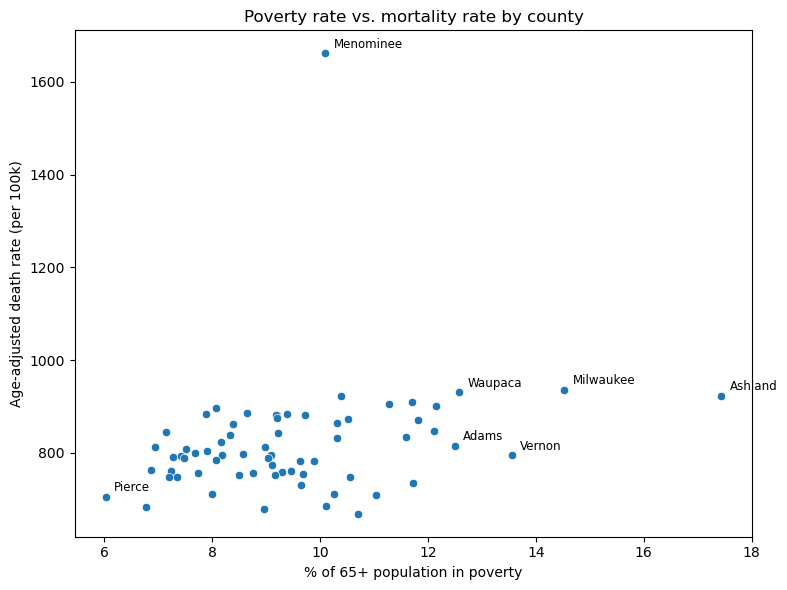

In [8]:
# Scatter plot of elderly poverty rate vs. age-adjusted mortality rate by county.
county_info['pct_65_in_poverty_pct'] = county_info['pct_65_in_poverty'] * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=county_info, x='pct_65_in_poverty_pct', y='death_rate', ax=ax)

mean_d, std_d = county_info['death_rate'].mean(), county_info['death_rate'].std()
mean_p, std_p = county_info['pct_65_in_poverty_pct'].mean(), county_info['pct_65_in_poverty_pct'].std()

for county, row in county_info.iterrows():
    if abs(row['death_rate'] - mean_d) > 1.5 * std_d or abs(row['pct_65_in_poverty_pct'] - mean_p) > 1.5 * std_p:
        ax.annotate(county, (row['pct_65_in_poverty_pct'], row['death_rate']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8.5)

ax.set_xlabel('% of 65+ population in poverty')
ax.set_ylabel('Age-adjusted death rate (per 100k)')
ax.set_title('Poverty rate vs. mortality rate by county')
plt.tight_layout()
plt.show()

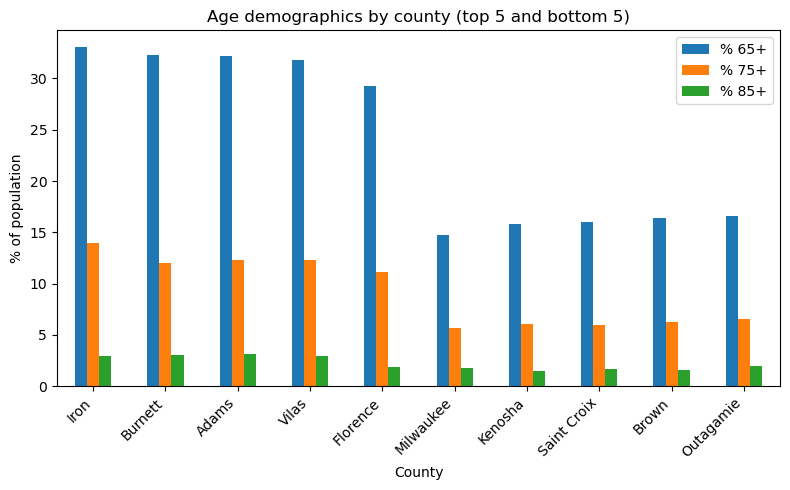

In [9]:
#Age demographics for the 5 counties with the highest and lowest proportion of residents aged 65+. 
top5 = county_info.nlargest(5, 'pct_65')
bot5 = county_info.nsmallest(5, 'pct_65')
sample = pd.concat([top5, bot5])

sample[['pct_65', 'pct_75', 'pct_85']].mul(100).plot(kind='bar', figsize=(8, 5))

plt.xlabel('County')
plt.ylabel('% of population')
plt.title('Age demographics by county (top 5 and bottom 5)')
plt.legend(['% 65+', '% 75+', '% 85+'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

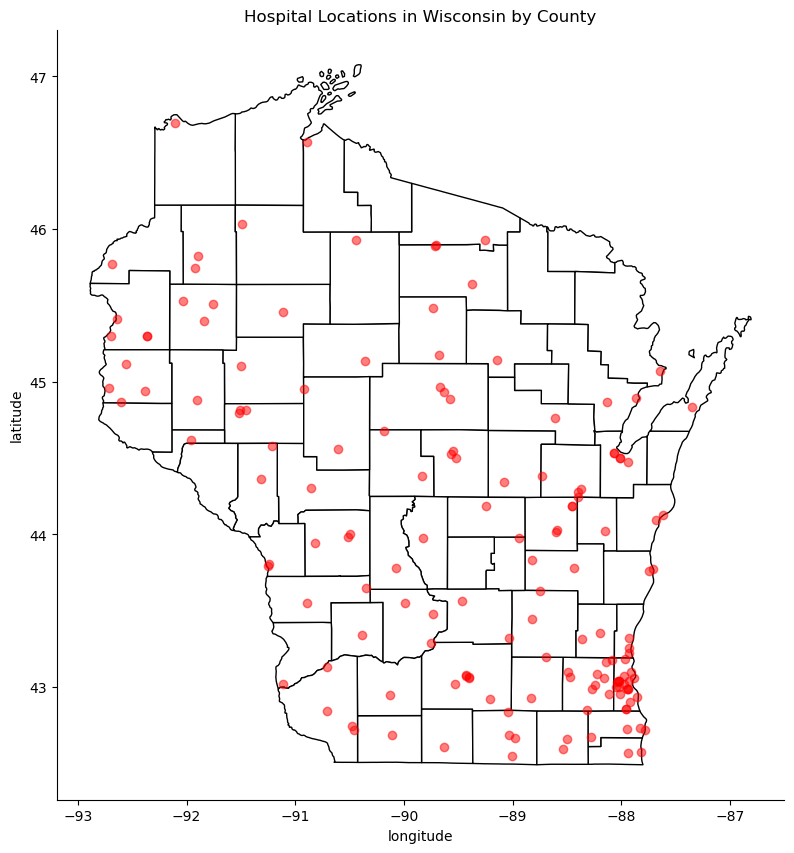

In [10]:
#Static map of Wisconsin counties with hospital locations overlaid.

us = geopandas.read_file('cb_2021_us_county_5m.zip')
wisco = us[us['STATE_NAME'] == 'Wisconsin']

hospitals = geopandas.read_file('Wisconsin_Hospitals.zip')
#fixing the Coordinate Reference System
hospitals = hospitals.to_crs(wisco.crs)

fig, gax = plt.subplots(figsize=(10,10))

wisco.plot(ax = gax, edgecolor='black',color='white')
hospitals.plot(ax = gax, color='red',alpha=0.5)

gax.set_xlabel('longitude')  
gax.set_ylabel('latitude')

gax.spines['top'].set_visible(False)
gax.spines['right'].set_visible(False)
gax.set_title('Hospital Locations in Wisconsin by County')
plt.show()

In [11]:
#to build plotly choropleths we need FIPS codes to match counties to map polygons
wisco['fips'] = '55' + wisco['COUNTYFP']
wisco['County'] = wisco['NAME'].str.strip()


county_info_reset = county_info.reset_index()  #turn 'County' back into a column

# Merge
county_fips = wisco[['County', 'fips']].copy()
county_data = county_info_reset.merge(county_fips, on='County', how='left')

/Users/alexandrawong/anaconda3/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/alexandrawong/anaconda3/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
county_data = county_data.merge(uninsured, on='County', how='left')
county_data = county_data[county_data['County'] != 'Wisconsin']#remove the summary column of wisconsin poverty rates
county_data['pct_65_in_poverty'] = county_data['pct_65_in_poverty'] * 100#convert the decomal value to a percentage by multiplying by 100
county_data['pct_65'] = county_data['pct_65'] * 100
county_data['pct_75'] = county_data['pct_75'] * 100
county_data['pct_85'] = county_data['pct_85'] * 100

#check for any nas after the merge. We want everything to match perfectly
print(county_data[county_data['uninsured_percent'].isna()][['County']])

Empty DataFrame
Columns: [County]
Index: []


## Plotly Maps

Making a plotly choropleth. Following example from lecture: [plotly documentation](https://plotly.com/python/choropleth-maps/). Plotly uses geojson.

In [13]:
#Load GeoJSON boundary file for all US counties from Plotly's public dataset repository.
#Same source used in the class lecture (notebook 24_interactive2).
res = urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json')
counties = json.load(res)

In [14]:
#Filter to counties in Wisconsin only
wi_features = [f for f in counties['features'] if f['properties']['STATE'] == '55']
wi_geojson = {'type': 'FeatureCollection', 'features': wi_features}

In [15]:
'''
Interactive choropleth map of Wisconsin county-level vulnerability indicators.

Built using Plotly Express for the choropleth layer and Dash for the interactive
dropdown. The dropdown allows the reader to switch between four variables:
  - Age-adjusted mortality rate
  - Elderly poverty rate
  - Elderly population share
  - Uninsured rate

The callback pattern (from class notebook 24_interactive2) connects the dropdown
selection (Input) to the choropleth figure (Output). Each time the user selects
a new variable, update_map() is called and returns a new figure.

Color scale: Reds (darker = higher/worse on each metric)
'''

from dash import Dash, dcc, html, callback, Output, Input



variable_options = {
    'death_rate': 'Age-Adjusted Mortality Rate (per 100k)',
    'pct_65_in_poverty': 'Elderly Poverty Rate (% of 65+ in poverty)',
    'pct_65': 'Elderly Population (% aged 65+)',
    'uninsured_percent': 'Uninsured Rate (% aged 18-64, ≤138% poverty)'#Percent uninsured in demographic group, people at or below 138% of poverty
}

app = Dash()#Initialize the app

#App layout
app.layout = [
    html.H1('Wisconsin County Vulnerability', style={'textAlign': 'center'}),
    dcc.Dropdown(
        #construct options dictionary
        options=[{'label': v, 'value': k} for k, v in variable_options.items()],
        value='death_rate',
        id='variable-dropdown'
    ),
    dcc.Graph(figure={}, id='choropleth')
]
#callback allows us to specify how the user can interact with the app.
@callback(
    Output('choropleth', 'figure'),
    Input('variable-dropdown', 'value')
)
def update_map(var_chosen):
    fig = px.choropleth(
        county_data,
        geojson=wi_geojson,
        locations='fips',
        color=var_chosen,
        color_continuous_scale='Reds',
        scope='usa',
        hover_name='County',
        labels={var_chosen: variable_options[var_chosen]},
        title=variable_options[var_chosen] + ' by County'
    )
    fig.update_geos(fitbounds='locations', visible=False)
    fig.update_layout(
        plot_bgcolor='white',
        margin={'r':0,'t':40,'l':0,'b':0},
        title={'x': 0.5, 'xanchor': 'center'}
    )
    return fig

app.run()

In [16]:
# One interactive html file is saved per variable, named choropleth_{variable}.html.

for var in variable_options:
    fig = update_map(var)
    fig.write_html(f'choropleth_{var}.html')# use the `write_html` method to convert the figure to an html file.